# Surface Sensitivities

This computes sensitivities using RMG's SurfaceReactor and an equivalent Cantera reactor and then compares them

In [43]:
import rmgpy.chemkin
import os

import cantera as ct
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import rmgpy.solver
# import rmgpy.quantity  #import Quantity
import rmgpy.rmg.listener
import rmgpy.rmg.settings

import rmgpy.tools.plot

# import matplotlib


# # logging.basicConfig(level=logging.DEBUG)
# import rmgpy.constants as constants
# from rmgpy.kinetics import SurfaceArrhenius, StickingCoefficient
# from rmgpy.molecule import Molecule
# from rmgpy.reaction import Reaction
# # from rmgpy.solver.surface import SurfaceReactor
# from rmgpy.species import Species
# from rmgpy.thermo import ThermoData, NASA, NASAPolynomial

## 1. Using RMG

### Load model

In [270]:
chemkin = 'rmg_run/chem_annotated-gas.inp'
chemkin_surf = 'rmg_run/chem_annotated-surface.inp'
spec_dict = 'rmg_run/species_dictionary.txt'

species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict, surface_path=chemkin_surf)

### Define Initial Conditions and Sensitive Species

In [316]:
def get_i_thing_rmg(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False

Ar = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[Ar]'), species_list)]
CH4 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='C'), species_list)]
O2 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[O][O]'), species_list)]
CO = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[C-]#[O+]'), species_list)]
CO2 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='O=C=O'), species_list)]
H2 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[H][H]'), species_list)]
X = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='*'), species_list)]

initial_gas_mole_fractions = {CH4: 0.296, O2: 0.147, Ar: 1.0 - 0.296 - 0.147}
initial_surface_coverages = {X: 1.0}
T = rmgpy.quantity.Quantity((700, 'K'))
P = rmgpy.quantity.Quantity((1, 'atm'))

surface_volume_ratio = rmgpy.quantity.Quantity((1.0, "m^-1"))
# surface_site_density = rmgpy.quantity.Quantity((2.72e-9, "mol/cm^2"))

surface_site_density = rmgpy.quantity.Quantity((2.483e-09, "mol/cm^2"))


termination = rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity((1.0, 's')))
sensitive_species = [CO, H2]

reaction_system = rmgpy.solver.surface.SurfaceReactor(
    T,
    P,
    n_sims=1,
    initial_gas_mole_fractions=initial_gas_mole_fractions,
    initial_surface_coverages=initial_surface_coverages,
    surface_volume_ratio=surface_volume_ratio,
    surface_site_density=surface_site_density,
    sensitive_species=sensitive_species,
    sensitivity_threshold=1e-3,
    termination=[termination],
)


### Set up concentration and sensitivity CSV writers

In [317]:
output_directory = './'
os.makedirs(os.path.join(output_directory, 'solver'), exist_ok=True)
reaction_system_index = 0
sens_worksheet = []
for spec in sensitive_species:
    csvfile_path = os.path.join(output_directory, 'solver',
                                'sensitivity_{0}_SPC_{1}.csv'.format(reaction_system_index + 1, spec.index))
    sens_worksheet.append(csvfile_path)

reaction_system.attach(rmgpy.rmg.listener.SimulationProfileWriter(output_directory, reaction_system_index, species_list))
reaction_system.attach(rmgpy.rmg.listener.SimulationProfilePlotter(output_directory, reaction_system_index, species_list))

In [318]:
simulator_settings = rmgpy.rmg.settings.SimulatorSettings()  # defaults
model_settings = rmgpy.rmg.settings.ModelSettings()  # defaults
model_settings.tol_move_to_core = 1e5
model_settings.tol_interrupt_simulation = 1e5
model_settings.tol_keep_in_edge = 0.0

In [319]:
reaction_system.simulate(
    core_species=species_list,
    core_reactions=reaction_list,
    edge_species=[],
    edge_reactions=[],
    surface_species=[],
    surface_reactions=[],
    model_settings=model_settings,
    simulator_settings=simulator_settings,
    sensitivity=True,
    sens_worksheet=sens_worksheet,
)

(True, False, [], [], [], 1.000722686995827, 0.0)

In [320]:
# retrieve the data from the csv
# You could use pandas to get it more directly, but this is fine
simulation_outfile = os.path.join(output_directory, 'solver', f'simulation_1_{len(species_list):d}.csv')
times, data = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels = [d.label for d in data]

### Plot some quick results

Text(0.5, 1.0, 'Gas Concentrations vs. Time')

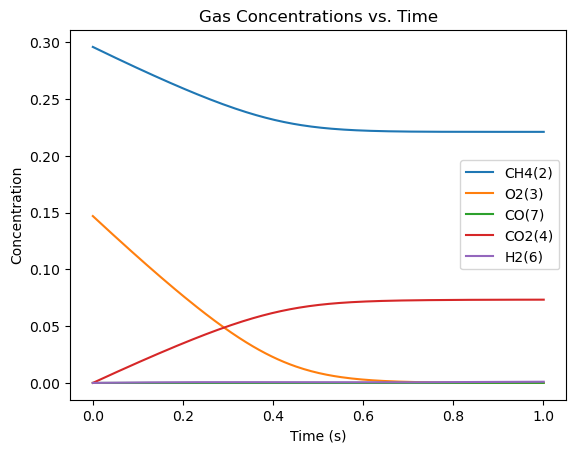

In [321]:
plt.plot(times.data, data[data_labels.index(CH4.to_chemkin())].data, label=CH4.to_chemkin())
plt.plot(times.data, data[data_labels.index(O2.to_chemkin())].data, label=O2.to_chemkin())
plt.plot(times.data, data[data_labels.index(CO.to_chemkin())].data, label=CO.to_chemkin())
plt.plot(times.data, data[data_labels.index(CO2.to_chemkin())].data, label=CO2.to_chemkin())
plt.plot(times.data, data[data_labels.index(H2.to_chemkin())].data, label=H2.to_chemkin())
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Concentration')
plt.title('Gas Concentrations vs. Time')

In [322]:
surf.site_density

2.4829999999999998e-08

## 2. Using Cantera

In [323]:
# mech_yaml = 'rmg_run/chem_annotated.yaml'
mech_yaml = 'rmg_run/chem_annotated-gas.yaml'

gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])

# check that the species and reactions match up between RMG and Cantera
assert len(species_list) == gas.n_species + surf.n_species
assert len(reaction_list) == gas.n_reactions + surf.n_reactions

for i in range(gas.n_species):
    assert str(species_list[i].to_chemkin()) == str(gas.species_names[i])
for i in range(surf.n_species):
    assert str(species_list[i + gas.n_species].to_chemkin()) == str(surf.species_names[i])


def same_reaction(rmg_rxn, ct_rxn):
    # really hacky way to do this, but whatever
    rmg_r = set([str(x.to_chemkin()) for x in rmg_rxn.reactants])
    rmg_p = set([str(x.to_chemkin()) for x in rmg_rxn.products])
    rmg_r = rmg_r - set(['Ar'])
    rmg_p = rmg_p - set(['Ar'])
    rmg_val = list(set(sorted(list(rmg_r) + list(rmg_p))))
    
    ct_r = set(ct_rxn.reactants.keys())
    ct_p = set(ct_rxn.products.keys())
    ct_val = list(set(sorted(list(ct_r) + list(ct_p))))
    return ct_val == rmg_val

for i in range(gas.n_reactions):
    assert same_reaction(reaction_list[i], gas.reactions()[i])
for i in range(surf.n_reactions):
    assert same_reaction(reaction_list[i + gas.n_reactions], surf.reactions()[i])


In [324]:
surface_site_density.value_si

2.4829999999999998e-05

In [310]:
surface_site_density

(2.72e-09,'mol/cm^2')

In [308]:
surface_site_density.value_si * REACTOR_AREA

1.5622853195164077e-06

In [309]:
surface_site_density.value_si

2.72e-05

In [300]:
ct.gas_constant * T.value_si / ct.one_atm

57.440156256671784

In [330]:
np.sum(surf.concentrations) # kmols sites

2.482999999986359e-08

In [329]:
surf.site_density

2.4829999999999998e-08

In [327]:
gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])

initial_gas_mole_fractions_ct = {x.to_chemkin(): v for x, v in initial_gas_mole_fractions.items()}
initial_surface_coverages_ct = {x.to_chemkin(): v for x, v in initial_surface_coverages.items()}



REACTOR_VOLUME = 8.314 * T.value_si / ct.one_atm
REACTOR_AREA = REACTOR_VOLUME * surface_volume_ratio.value_si


# convert between area
# volume = ct.gas_constant 0.5744022  # m^3
# surface_area = volume * surface_volume_ratio.value_si * 10

gas.TPX = T.value_si, P.value_si, initial_gas_mole_fractions_ct
# gas_reactor = ct.IdealGasReactor(gas, energy='off')
gas_reactor = ct.IdealGasConstPressureReactor(gas, energy='off')
surf.TP = T.value_si, P.value_si
surf.coverages = initial_surface_coverages_ct
gas_reactor.volume = REACTOR_VOLUME
surf_reactor = ct.ReactorSurface(surf, gas_reactor, A=REACTOR_AREA *1000)

sim = ct.ReactorNet([gas_reactor])


# # Add all reactions and species as sensitive parameters
# for i in range(gas.n_reactions):
#     gas_reactor.add_sensitivity_reaction(i)
# for i in range(surf.n_reactions):
#     surf_reactor.add_sensitivity_reaction(i)
# # if not manual_sens:  # be careful here. This affects the order of net.sensitivity
# for i in range(gas.n_species):
#     gas_reactor.add_sensitivity_species_enthalpy(i)
# surface sensitivity species not yet implemented in Cantera
# V = constants.R * self.T.value_si * total_gas_moles / self.P_initial.value_si


times = [sim.time]
volumes = [gas_reactor.volume]
pressures = [gas.P]
temperatures = [gas.T]

# also save enthalpies for sensitiviity
# enthaplies = [gas.standard_enthalpies_RT * ct.gas_constant * gas.T]

# order of all_sensitivities is gas reactions, surface reactions, gas species, surface species
# all_sensitivities = [np.zeros((len(species_list) + len(reaction_list), len(sensitive_species)))]
all_concentrations = [np.concatenate((gas_reactor.thermo.X, surf.concentrations / surf.site_density))]
# enthaplies = [np.concatenate((gas.standard_enthalpies_RT * ct.gas_constant * gas.T, surf.standard_enthalpies_RT * ct.gas_constant * surf.T))]

while sim.time < termination.time.value_si:
    sim.step()
    times.append(sim.time)
    volumes.append(gas_reactor.volume)
    pressures.append(gas.P)
    temperatures.append(gas.T)
    # all_concentrations.append(np.concatenate((gas_reactor.thermo.X, surf.concentrations / surf.site_density)))
    all_concentrations.append(np.concatenate((gas.X, surf.concentrations / surf.site_density)))


times = np.array(times)
volumes = np.array(volumes)
pressures = np.array(pressures)
temperatures = np.array(temperatures)
all_concentrations = np.array(all_concentrations)

#     enthaplies.append(np.concatenate((gas.standard_enthalpies_RT * ct.gas_constant * gas.T, surf.standard_enthalpies_RT * ct.gas_constant * surf.T)))
#     sens_mat = np.zeros((len(species_list) + len(reaction_list), len(sensitive_species)))
#     # record sensitivities
#     for j in range(len(sensitive_species)):
#         for i in range(gas.n_reactions):  # gas reactions
#             sens_mat[i, j] = sim.sensitivity(sensitive_species[j].to_chemkin(), i)
#         # if not manual_sens:
#         for i in range(gas.n_species):  # gas species
#             sens_mat[len(reaction_list) + i, j] = sim.sensitivity(sensitive_species[j].to_chemkin(), len(reaction_list) + i) * 4.184 * 1e6  # convert from J/kmol to kcal / mol 
#         for i in range(len(reaction_list) - gas.n_reactions):  # surface reactions
#             sens_mat[gas.n_reactions + i, j] = sim.sensitivity(sensitive_species[j].to_chemkin(), gas.n_reactions + i)
#         # Not Yet Implemented in Cantera
#         # for i in range(n_surf_spcs):  # surface species
#         #     sens_mat[len(self.reaction_list) + gas.n_species + i, j] = net.sensitivity(sensitive_species[j].to_chemkin(), len(self.reaction_list) + gas.n_species + i)                

#     all_sensitivities.append(sens_mat)

# all_sensitivities = np.array(all_sensitivities)

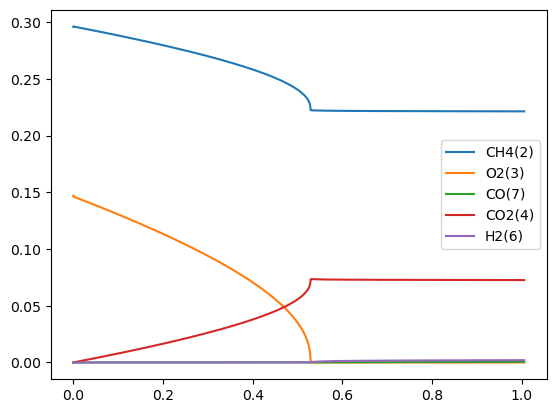

In [328]:
# plot some quick results
plt.plot(times, all_concentrations[:, gas.species_names.index(CH4.to_chemkin())], label=CH4.to_chemkin())
plt.plot(times, all_concentrations[:, gas.species_names.index(O2.to_chemkin())], label=O2.to_chemkin())
plt.plot(times, all_concentrations[:, gas.species_names.index(CO.to_chemkin())], label=CO.to_chemkin())
plt.plot(times, all_concentrations[:, gas.species_names.index(CO2.to_chemkin())], label=CO2.to_chemkin())
plt.plot(times, all_concentrations[:, gas.species_names.index(H2.to_chemkin())], label=H2.to_chemkin())
plt.legend()

In [288]:
pressures

array([101325.        , 101325.        , 101324.9999983 , ...,
       101392.97558863, 101393.3397164 , 101393.70050014])

In [130]:
times.shape

(2085,)

In [75]:



termination = rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity((1.0, 's')))
sensitive_species = [CO, H2]


In [78]:
termination.time.value_si

1.0

In [ ]:
gas_reactor = ct.IdealGasConstPressureReactor(gas, energy='off')  # isothermal to match simple reactor

In [ ]:
ct.IdealGasReactor

In [ ]:
gas.TPX = T, P, initial_gas_mole_fractions_ct

In [67]:
initial_gas_mole_fractions

{Species(index=2, label="CH4", thermo=NASA(polynomials=[NASAPolynomial(coeffs=[4.20542,-0.00535559,2.51124e-05,-2.13763e-08,5.97526e-12,-10161.9,-0.921283], Tmin=(100,'K'), Tmax=(1084.12,'K')), NASAPolynomial(coeffs=[0.908259,0.0114541,-4.57174e-06,8.29193e-10,-5.66316e-14,-9719.97,13.9931], Tmin=(1084.12,'K'), Tmax=(5000,'K'))], Tmin=(100,'K'), Tmax=(5000,'K'), comment="""Thermo library: primaryThermoLibrary"""), molecule=[Molecule(smiles="C")], molecular_weight=(16.0425,'amu')): 0.296,
 Species(index=3, label="O2", thermo=NASA(polynomials=[NASAPolynomial(coeffs=[3.53732,-0.00121572,5.3162e-06,-4.89446e-09,1.45846e-12,-1038.59,4.68368], Tmin=(100,'K'), Tmax=(1074.55,'K')), NASAPolynomial(coeffs=[3.15382,0.00167804,-7.69974e-07,1.51275e-10,-1.08782e-14,-1040.82,6.16756], Tmin=(1074.55,'K'), Tmax=(5000,'K'))], Tmin=(100,'K'), Tmax=(5000,'K'), comment="""Thermo library: primaryThermoLibrary"""), molecule=[Molecule(smiles="[O][O]")], molecular_weight=(31.9988,'amu')): 0.147,
 Species(labe

In [ ]:
# Save the species enthalpies
                # reset all values to zero that may have been computed by Cantera
                for t in range(len(all_sensitivities)):
                    all_sensitivities[t][len(self.reaction_list):, :] = 0.0

                for z in range(len(self.species_list)):

                    # perturb the enthalpy by 0.1 kcal/mol
                    saved_thermo = copy.deepcopy(self.species_list[z].thermo)
                    DELTA_J_MOL = 418.4
                    if self.species_list[z].contains_surface_site():
                        DELTA_J_MOL = 418.4
                    perturb_species(self.species_list[z], DELTA_J_MOL)

                    if not surface_mech:
                        gas = ct.Solution(
                            thermo='IdealGas',
                            kinetics='GasKinetics',
                            species=[x.to_cantera(use_chemkin_identifier=True) for x in self.species_list],
                            reactions=[x.to_cantera(use_chemkin_identifier=True) for x in self.reaction_list],
                        )
                    else:
                        gas, surf = make_ct_interface(self.species_list, self.reaction_list)

                    gas.TPX = T, P, initial_mole_fractions
                    gas_reactor = ct.IdealGasConstPressureReactor(gas, energy='off')  # isothermal to match simple reactor

                    if surface_mech:
                        # gas_reactor = ct.IdealGasReactor(gas, energy='off')

                        surf.TP = T, P
                        surf.coverages = initial_surface_coverages
                        surf_reactor = ct.ReactorSurface(surf, gas_reactor)

                    net = ct.ReactorNet([gas_reactor])

                    assert net.time == 0
                    sens_times = [net.time]
                    sens_all_concentrations = [gas_reactor.thermo.X]
                    if surface_mech:
                        sens_all_concentrations = [np.concatenate((gas_reactor.thermo.X, surf.concentrations / surf.site_density))]

                    # Run the Reaction Simulation
                    sens_volumes = [gas_reactor.volume]
                    # sens_pressures = [gas.P]
                    # sens_temperatures = [gas.T]
                    for t in times[1:]:  # first time entry is 0, so skip it
                        try:
                            net.advance(t)
                        except ct._cantera.CanteraError:
                            # sensitivity can break results, so just append nans? somehow signal the simulation failed
                            break
                        sens_times.append(net.time)
                        sens_volumes.append(gas_reactor.volume)
                        # sens_pressures.append(gas.P)
                        # sens_temperatures.append(gas.T)
                        if not surface_mech:
                            sens_all_concentrations.append(gas_reactor.thermo.X)
                        else:
                            sens_all_concentrations.append(np.concatenate((gas_reactor.thermo.X, surf.concentrations / surf.site_density)))

                    # reset the thermo
                    self.species_list[z].thermo = saved_thermo

                    assert np.all(np.array(times) == np.array(sens_times))
                    assert len(sens_all_concentrations) == len(all_concentrations)

                    # calculate the thermo sensitivity
                    for j in range(len(sensitive_species)):
                        sensitive_species_index = self.species_list.index(sensitive_species[j])
                        assert sensitive_species_index >= 0
                        for t in range(len(all_sensitivities)):

                            y_perturbed = sens_all_concentrations[t][sensitive_species_index]
                            y = all_concentrations[t][sensitive_species_index]

                            if y == 0:
                                continue
                            sensitivity = ((y_perturbed - y) / y) / (DELTA_J_MOL / 4184)
                            all_sensitivities[t][len(self.reaction_list) + z, j] = sensitivity